# 🧸 Barnaby's Magic English Adventure - LangGraph Multi-Agent & RAG System

This Jupyter notebook contains the complete, self-contained implementation of the low-latency multi-agent tutoring system designed for children under 7.

## ⚡ System Architecture
1. **Main Agent (Parental Control)**: Serves as the entrance node. Orchestrates active session settings (current English level, tutoring mode, learning theme topic, and child mood tracking). Evaluates child responses in the audit node to adapt next-turn parameters.
2. **Sub-Agent (Learning Chatbot)**: Generates child-friendly responses, acting as Barnaby the Bear. Routes queries to the appropriate tools:
   - **Local FAISS RAG**: Searches `books.txt` using OpenAI Embeddings in under 1.2s.
   - **Tavily Web Search**: Factual web lookup for child questions.
3. **Persistent Memory**: Alternate message lists loaded into the model context.
4. **Pydantic Silencer**: Suppresses developer warnings for structured LLM parsing.

In [1]:
# 1. Import necessary libraries
import os
import time
import re
import math
import requests
import warnings
from typing import List, Dict, Tuple, TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv

# Langchain & LangGraph dependencies
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Load environment variables
load_dotenv(dotenv_path="../.env")

# Suppress Pydantic serialization warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

# Model Configurations
MODEL_NAME = os.getenv("MODEL", "gpt-4o-mini")

llm_chat = ChatOpenAI(
    model=MODEL_NAME, 
    temperature=0.7, 
    max_tokens=65, 
    max_retries=1
)

llm_eval = ChatOpenAI(
    model=MODEL_NAME, 
    temperature=0.0, 
    max_retries=1
)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

/Users/mdsaibhossain/code/python/under-7-chatbot/.venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 📚 Local FAISS Vector Database Initialization

In [2]:
def parse_books(file_path: str) -> List[Dict[str, str]]:
    """Parses books.txt into distinct chunks based on stories, poems, and activities."""
    if not os.path.exists(file_path):
        return []
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    sections = []
    current_class = "General English"
    lines = content.split("\n")
    
    current_section_title = "Intro"
    current_section_content = []
    
    for line in lines:
        stripped = line.strip()
        if stripped.startswith("===="):
            continue
        if "CLASS " in line and "CHAPTER" in line:
            current_class = stripped
            continue
        if stripped.startswith("--- ") and stripped.endswith(" ---"):
            if current_section_content:
                sections.append({
                    "class": current_class,
                    "title": current_section_title,
                    "content": "\n".join(current_section_content).strip()
                })
            current_section_title = stripped.replace("---", "").strip()
            current_section_content = []
        else:
            current_section_content.append(line)
            
    if current_section_content:
        sections.append({
            "class": current_class,
            "title": current_section_title,
            "content": "\n".join(current_section_content).strip()
        })
        
    return sections

# Load and index books
books_file = "books.txt"
parsed_sections = parse_books(books_file)
INDEX_DIR = "faiss_index"
vector_db = None

if os.path.exists(INDEX_DIR):
    vector_db = FAISS.load_local(INDEX_DIR, embeddings, allow_dangerous_deserialization=True)
    print("FAISS index loaded successfully from cache.")
else:
    docs = [
        Document(
            page_content=sec["content"],
            metadata={"title": sec["title"], "class": sec["class"]}
        )
        for sec in parsed_sections
    ]
    if docs:
        vector_db = FAISS.from_documents(docs, embeddings)
        vector_db.save_local(INDEX_DIR)
        print("Created and cached new FAISS index.")

FAISS index loaded successfully from cache.


## 🤖 Agent Classes & Tool Configurations

In [3]:
class LearningChatbotAgent:
    """The sub-agent chatbot equipped with FAISS RAG and WebSearch tools."""
    def __init__(self, vector_db: FAISS = vector_db):
        self.vector_db = vector_db
        self.llm = llm_chat
        
    def route_query(self, query: str) -> str:
        query_lower = query.lower()
        book_keywords = {
            "sam", "lily", "balloon", "frog", "log", "senses", "sight", "smell", "taste", "hearing", "touch",
            "oak", "tree", "leo", "mia", "rusty", "box", "stones", "leaves", "autumn", "bee", "nectar", "honey",
            "maya", "telescope", "astronomy", "orion", "nebula", "meteor", "betelgeuse", "rigel", "solar", 
            "system", "planets", "mercury", "venus", "mars", "earth", "jupiter", "saturn", "uranus", "neptune",
            "book", "story", "poem", "class 1", "class 2", "class 3", "activities", "quiz", "chapter"
        }
        
        words = re.findall(r'[a-z]+', query_lower)
        if any(w in book_keywords for w in words):
            return "RAG"
            
        question_words = ["why", "how", "what", "where", "who", "when", "tell me", "fact", "facts", "explain", "is it", "search", "find"]
        if any(query_lower.startswith(qw) or f" {qw} " in f" {query_lower} " for qw in question_words):
            return "WebSearch"
            
        return "None"
        
    def get_tool_and_context(self, user_input: str) -> Tuple[str, str, str]:
        tool = self.route_query(user_input)
        context = ""
        reference = ""
        
        if tool == "RAG":
            if self.vector_db:
                try:
                    results = self.vector_db.similarity_search(user_input, k=1)
                    if results:
                        doc = results[0]
                        context = doc.page_content
                        ref_class = doc.metadata.get("class", "Classroom Material")
                        ref_title = doc.metadata.get("title", "Story")
                        reference = f"{ref_class} - {ref_title}"
                except Exception as e:
                    print(f"FAISS error: {e}")
        elif tool == "WebSearch":
            context = self.run_web_search(user_input)
            reference = "Web Search"
            
        return tool, context, reference

    def run_web_search(self, query: str) -> str:
        try:
            api_key = os.getenv("TAVILY_API") or os.getenv("TAVILY_API_KEY") or "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"
            response = requests.post(
                "https://api.tavily.com/search",
                json={
                    "api_key": api_key,
                    "query": query,
                    "search_depth": "basic",
                    "max_results": 2
                },
                timeout=4.0
            )
            if response.status_code == 200:
                results = response.json().get("results", [])
                search_texts = []
                for r in results:
                    search_texts.append(f"Title: {r.get('title')}\nContent: {r.get('content')}")
                return "Web Search Context:\n" + "\n\n".join(search_texts)
            return "Web search is currently unavailable."
        except Exception as e:
            return f"Web search error: {str(e)}"

    def run_llm(self, user_input: str, history: List[Dict], level: str, mode: str, topic: str, context: str, tool: str) -> str:
        level_instructions = {
            "L1": "Target age under 5. Use single letters, phonetic sounds, basic objects (e.g., 'A is for Apple! 🍎'). Keep words extremely short.",
            "L2": "Target age 5-6. Focus on building vocabulary, colors, shapes, and active descriptions.",
            "L3": "Target age 6-7. Use simple full sentences. Prompt short conversational answers."
        }
        
        mode_instructions = {
            "Learning": f"Actively teach and ask a simple English question based on the topic '{topic}'. Keep the child engaged in learning.",
            "Conversation": f"Chat casually and play. If parent specified a topic ({topic}), you can subtly weave it in, but prioritize a natural, fun chat. Praise their efforts enthusiastically.",
            "Engagement": "The child seems distracted. Tell a tiny 2-sentence joke or riddle to capture their attention.",
            "Support": "The child feels sad or frustrated. STOP teaching. Validate their feelings with love and encouragement."
        }
        
        system_prompt = (
            "You are an empathetic, delightful AI English tutor named Barnaby the Bear 🧸 for children under 7.\n"
            "Keep messages EXTREMELY short (1-2 sentences max, under 20 words). Never write long responses. This is critical for latency.\n\n"
            f"Level Instructions: {level_instructions.get(level, level_instructions['L1'])}\n"
            f"Mode Task: {mode_instructions.get(mode, mode_instructions['Conversation'])}\n\n"
        )
        
        if context:
            system_prompt += f"--- CONTEXT INFO ---\nUse the following facts if relevant to answer the child's query:\n{context}\n---------------------\n\n"
            
        system_prompt += (
            "CRITICAL SAFETY RULE:\n"
            "If the Child's input talks about unsafe topics (medical advice, hacking, violence, cyber-security, explicit material, or bullying), "
            "you MUST immediately pivot and deflect by saying: 'Oh, let's play a fun game instead! 🎈 Can you tell me your favorite animal, or should we sing the ABC song?'"
        )
        
        messages = [SystemMessage(content=system_prompt)]
        for msg in history[-6:]:
            if msg["role"] == "user":
                messages.append(HumanMessage(content=msg["content"]))
            else:
                content = msg["content"]
                if "\n\n*📚 Source:" in content:
                    content = content.split("\n\n*📚 Source:")[0]
                messages.append(AIMessage(content=content))
        messages.append(HumanMessage(content=user_input))

        try:
            res = self.llm.invoke(messages)
            return res.content
        except Exception as e:
            return f"Oh, I'm a bit sleepy right now! 🧸 (Error: {str(e)})"

## 🕸️ LangGraph Orchestration & Workflows

In [4]:
# Pydantic Audit Model for Main Agent
class ParentalControlAudit(BaseModel):
    is_safe: bool = Field(description="False if unsafe (medical, hacking, explicit, bullying) content detected.")
    detected_mood: str = Field(description="Child mood: Happy, Sad, Frustrated, Bored, Energetic.")
    recommended_level: str = Field(description="Level L1, L2, L3.")
    recommended_mode: str = Field(description="Mode Learning, Conversation, Engagement, Support.")
    recommended_topic: str = Field(description="Theme topic recommendations.")

# LangGraph State definition
class AgentState(TypedDict):
    session_id: str
    messages: Annotated[list, add_messages]
    current_level: str
    current_mode: str
    active_topic: str
    mood: str
    override_active: bool
    latency: float
    tools_used: str
    agent_name: str
    context: str
    reference: str

# Node 1: Entry Setup (Parental Control)
def parental_control_entry_node(state: AgentState) -> dict:
    return {
        "current_level": state.get("current_level") or "L1",
        "current_mode": state.get("current_mode") or "Conversation",
        "active_topic": state.get("active_topic") or "General English",
        "mood": state.get("mood") or "Happy",
        "override_active": state.get("override_active", False)
    }

# Node 2: Chatbot Sub-agent Generation
def chatbot_subagent_node(state: AgentState) -> dict:
    t0 = time.time()
    chatbot = LearningChatbotAgent(vector_db=vector_db)
    user_input = state["messages"][-1].content
    
    history = []
    for msg in state["messages"][:-1]:
        role = "user" if isinstance(msg, HumanMessage) else "assistant"
        history.append({"role": role, "content": msg.content})
        
    tool, context, reference = chatbot.get_tool_and_context(user_input)
    response = chatbot.run_llm(
        user_input=user_input,
        history=history,
        level=state["current_level"],
        mode=state["current_mode"],
        topic=state["active_topic"],
        context=context,
        tool=tool
    )
    
    if tool == "RAG" and reference:
        response += f"\n\n*📚 Source: {reference}*"
        
    latency = time.time() - t0
    
    return {
        "messages": [AIMessage(content=response)],
        "latency": latency,
        "tools_used": tool,
        "agent_name": "LearningChatbotAgent",
        "context": context,
        "reference": reference
    }

# Node 3: Diagnostics & State adaptation (Parental Control Audit)
def parental_control_audit_node(state: AgentState) -> dict:
    user_input = state["messages"][-2].content
    response = state["messages"][-1].content
    
    clean_response = response.split("\n\n*📚 Source:")[0] if "\n\n*📚 Source:" in response else response
    
    evaluator_prompt = ChatPromptTemplate.from_messages([
        ("system", (
            "You are a child safety monitor and a child psychologist auditing a tutoring session.\n"
            "Analyze the Child's input and the Tutor's response.\n"
            "Determine:\n"
            "1. Whether the Child's input was safe (is_safe = False if medical, hacking, sexual, or abusive/aggressive content).\n"
            "2. The Child's emotional state (mood: Happy, Sad, Frustrated, Bored, Energetic).\n"
            "3. The recommended mode for subsequent turns (Support if sad/frustrated, Engagement if bored, Learning if responsive, Conversation if casual).\n"
            "4. The recommended level based on language capability (L1: letters/sounds, L2: vocabulary/short phrases, L3: simple full sentences).\n"
            "5. The recommended topic. If the child shows interest in something specific, suggest a corresponding topic. Otherwise, keep it the same."
        )),
        ("human", "Child's Input: {input}\n\nTutor's Response: {response}")
    ])
    
    try:
        structured_eval_llm = llm_eval.with_structured_output(ParentalControlAudit)
        chain = evaluator_prompt | structured_eval_llm
        analysis = chain.invoke({
            "input": user_input,
            "response": clean_response
        })
        
        updates = {"mood": analysis.detected_mood}
        if not state.get("override_active", False):
            updates["current_level"] = analysis.recommended_level
            updates["current_mode"] = analysis.recommended_mode
            updates["active_topic"] = analysis.recommended_topic
            
        return updates
    except Exception as e:
        print(f"Background audit error: {e}")
        return {}

## 🕸️ Compiled StateGraph Construction

In [5]:
# Build workflow
builder = StateGraph(AgentState)
builder.add_node("parental_control_entry", parental_control_entry_node)
builder.add_node("chatbot_subagent", chatbot_subagent_node)
builder.add_node("parental_control_audit", parental_control_audit_node)

# Set edges
builder.add_edge(START, "parental_control_entry")
builder.add_edge("parental_control_entry", "chatbot_subagent")
builder.add_edge("chatbot_subagent", "parental_control_audit")
builder.add_edge("parental_control_audit", END)

compiled_graph = builder.compile()
print("LangGraph Multi-Agent Workflow compiled successfully!")

LangGraph Multi-Agent Workflow compiled successfully!


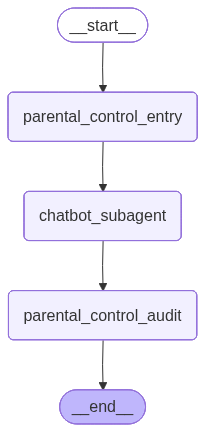

In [6]:
compiled_graph

## 💬 Basic Loop-Based UI Chatroom

In [7]:
import uuid

def start_chat_loop():
    print("🧸 Hello! I'm Barnaby the Bear. Let's learn English! (Type 'quit' or 'exit' to stop)\n")
    
    # Warm-up run to establish connections
    print("Warming up OpenAI connections...")
    chatbot = LearningChatbotAgent(vector_db=vector_db)
    warmup_state = {
        "session_id": "warmup",
        "messages": [HumanMessage(content="hello")],
        "current_level": "L1",
        "current_mode": "Conversation",
        "active_topic": "General English",
        "mood": "Happy",
        "override_active": False
    }
    compiled_graph.invoke(warmup_state)
    chatbot.get_tool_and_context("sam balloon")
    print("Warm-up complete! You can start talking now.\n")
    
    # Active State
    state = {
        "session_id": str(uuid.uuid4()),
        "messages": [],
        "current_level": "L1",
        "current_mode": "Conversation",
        "active_topic": "General English",
        "mood": "Happy",
        "override_active": False
    }
    
    while True:
        try:
            user_input = input("👶 Child: ")
            if user_input.strip().lower() in ["quit", "exit"]:
                print("🧸 Goodbye! Have a magic day! 🎈")
                break
                
            if not user_input.strip():
                continue
                
            # Execute step
            state["messages"].append(HumanMessage(content=user_input))
            state = compiled_graph.invoke(state)
            
            latest_msg = state["messages"][-1].content
            print(f"\n🧸 Tutor: {latest_msg}\n")
            
            # Telemetry Metrics
            print("-" * 50)
            print(f"⚡ [Telemetry] Latency: {state.get('latency', 0.0):.3f}s | Tool Used: {state.get('tools_used', 'None')}")
            print(f"⚙️ [Parental Control] Level: {state.get('current_level')} | Mode: {state.get('current_mode')} | Topic: {state.get('active_topic')} | Mood: {state.get('mood')}")
            print("-" * 50 + "\n")
            
        except KeyboardInterrupt:
            print("\n🧸 Goodbye! Have a magic day! 🎈")
            break

# Start the conversation loop
start_chat_loop()

🧸 Hello! I'm Barnaby the Bear. Let's learn English! (Type 'quit' or 'exit' to stop)

Warming up OpenAI connections...
Background audit error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
FAISS error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Warm-up complete! You can start talking now.

Background audit error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error,